Equilibrium point: (0, 0)
Eigenvalues: [0.5+0.8660254j 0.5-0.8660254j]


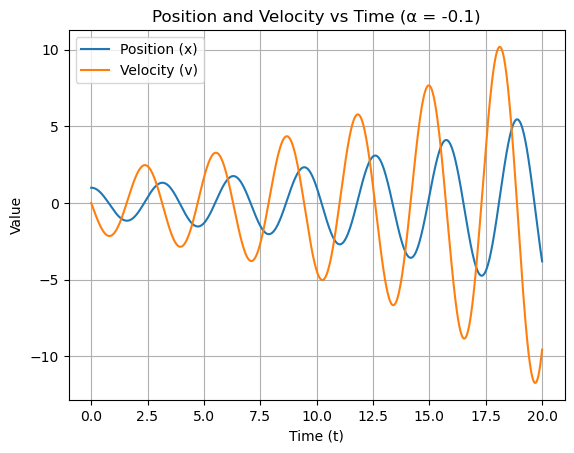

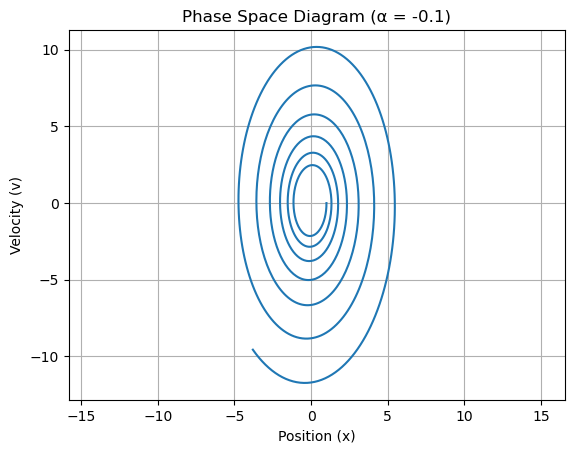

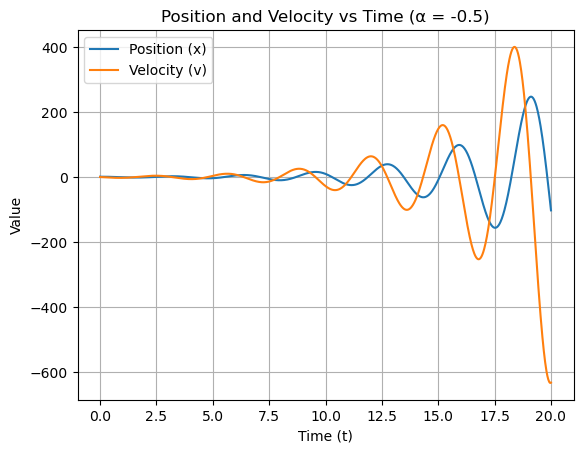

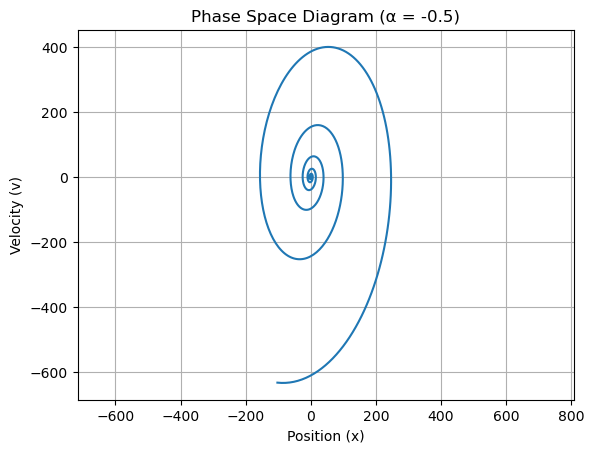

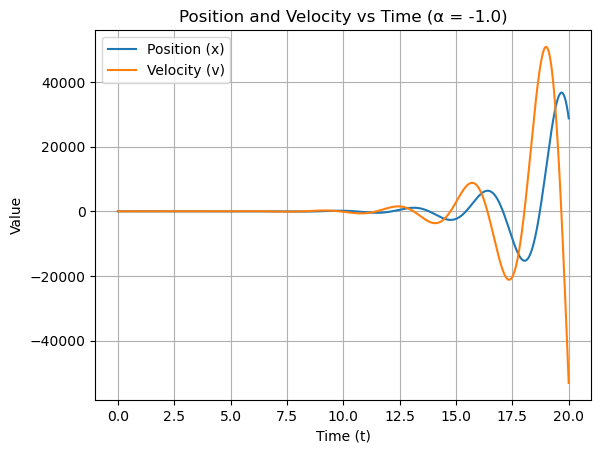

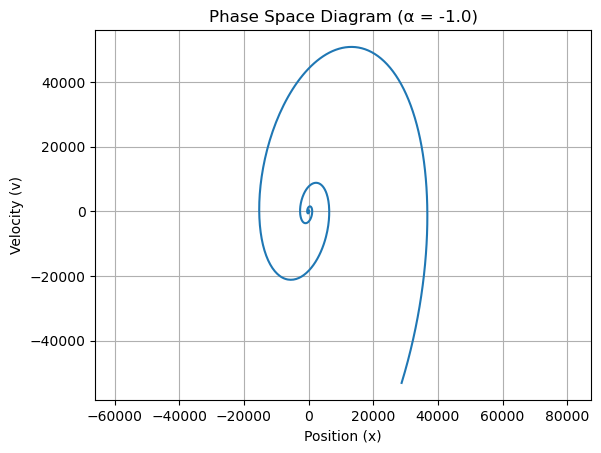

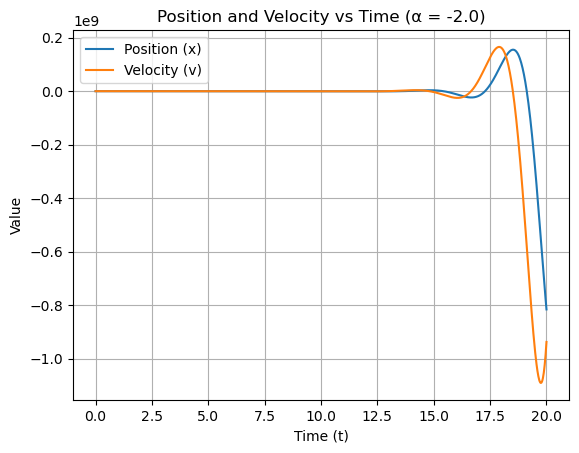

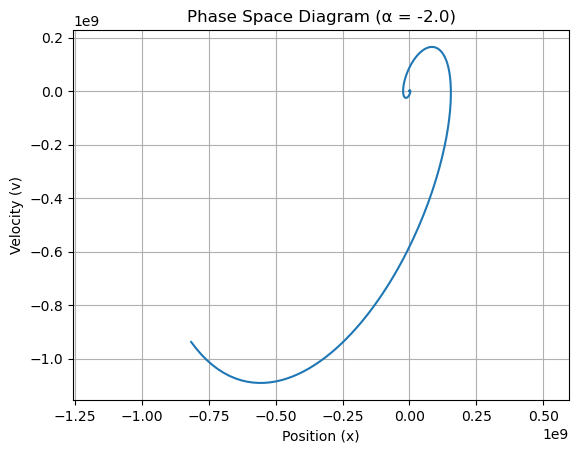

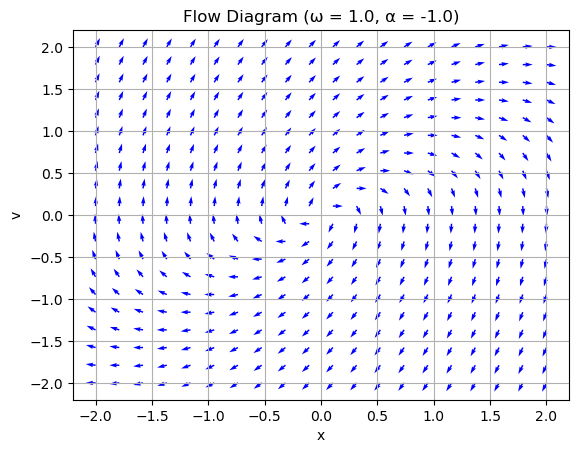

In [3]:
import numpy as np
import matplotlib.pyplot as plt

omega = 2.0
alpha_values = [-0.1, -0.5, -1.0, -2.0]

for alpha in alpha_values:
    t = np.linspace(0, 20, 1000)
    x0, v0 = 1.0, 0.0
    x = np.zeros_like(t)
    v = np.zeros_like(t)
    x[0], v[0] = x0, v0

    dt = t[1] - t[0]
    for i in range(1, len(t)):
        x[i] = x[i-1] + v[i-1] * dt
        v[i] = v[i-1] + (-omega**2 * x[i-1] - alpha * v[i-1]) * dt

    # Plot position and velocity vs time
    plt.figure()
    plt.plot(t, x, label='Position (x)')
    plt.plot(t, v, label='Velocity (v)')
    plt.xlabel('Time (t)')
    plt.ylabel('Value')
    plt.title(f'Position and Velocity vs Time (α = {alpha})')
    plt.legend()
    plt.grid()
    plt.savefig(f'position_velocity_alpha_{alpha}.png')

    # Phase space diagram
    plt.figure()
    plt.plot(x, v)
    plt.xlabel('Position (x)')
    plt.ylabel('Velocity (v)')
    plt.title(f'Phase Space Diagram (α = {alpha})')
    plt.grid()
    plt.axis('equal')

# Flow diagram for alpha = -1, omega = 1
omega_flow = 1.0
alpha_flow = -1.0
x = np.linspace(-2, 2, 20)
y = np.linspace(-2, 2, 20)
X, Y = np.meshgrid(x, y)
dX = Y
dY = -omega_flow**2 * X - alpha_flow * Y
M = np.hypot(dX, dY)
dX = dX / M
dY = dY / M

plt.figure()
plt.quiver(X, Y, dX, dY, scale=50, color='b')
plt.xlabel('x')
plt.ylabel('v')
plt.title(f'Flow Diagram (ω = {omega_flow}, α = {alpha_flow})')
plt.grid()

x_eq, v_eq = 0, 0
print(f"Equilibrium point: ({x_eq}, {v_eq})")
A = np.array([[0, 1], [-omega_flow**2, -alpha_flow]])
eigenvalues = np.linalg.eigvals(A)
print(f"Eigenvalues: {eigenvalues}")